In [ ]:
""" 
Author: Weronika Golletz

Updates:
2 Mar 2026: create notebook, plan it structure
"""

In [31]:
import sys
import os

# This adds the parent directory to the search path
sys.path.append(os.path.abspath(".."))


%load_ext autoreload
%autoreload 2
from src.mltoolbox import *

# import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Motivation

# Generate Synthetic Dataset

Let's generate a synthetic dataset to understand how metrics behave under different conditions:
1. Balanced dataset
2. Imbalanced dataset
3. ...

We assume the true labels are generated from a categorical distribution:
$$ y_{\text{true}} \sim \text{Categorical}(\pi)$$
where $\pi = (\pi_1,\dots,\pi_K)$, $\pi_k=P(Y=k)$, and $\sum_k \pi_k = 1$. This vector $\pi$ defines the class distribution.

It controls whether the dataset is:
- Balanced (all classes equally likely)
- Imbalanced (some classes rare).

We simulate, the classifier's behavior in the following way. First, define a matrix $P \in \mathbb{R}^{K\times K}$:
$$y_{\text{pred}} | y_{\text{true}} = k \sim \text{Categorical(P[k,:])}$$
The matrix encodes:
$$P_{k,j} = P(\hat{Y}=j | Y=k)$$

Thus, each row corresponds to: if the true class is $k$, how does the model distribute its predictions?

Each row of matrix $P$ must sum to $1$:
$$ \sum_j P_{k,j}=1 $$
The diagonal entries are the probabilities of correct predition, i.e. model accuracy for class $k$. The off-diagonal entries are probabilities of confusing class $k$ with class $j$. 

The matrix $P$ is sometimes called:
- transition matrix,
- noise matrix,
- conditional confusion matrix.
With this matrix we actively design the error structure.

We will create three cases of datasets:
1. **Balanced Dataset:** $$\pi = [\frac{1}{K},\dots,\frac{1}{K}]$$ Thus every class appears equally often. This dataset is used for understanding pure precision/recall trade-offs and to demonstrate the baselines.
2. **Imbalanced Dataset:** $$ \pi = [0.8,0.15,0.05]$$ Thus the class 0 dominate, class 2 is rare. This allows us to observe why accuracy can be misleading, why macro vs weighted metrics differ, and how minority recall behaves. Here, imbalance comes from the data, not the model.
3. **Structured Confusion:** </br>
 matrix $P$ is encoded for a specific failare pattern. Here, class 2 is often mistaken for class 1, i.e. $P_{2,1}$ is large. Thanks this example, we simulate realistic structure of similar-looking classes, semantic overlap and hard-to-distinguish categories. This helps us to observe: class-specific precision collapse, asymmetric confusion and impact on macro-F1.

In [17]:
# --- Balanced Case ---
K = 3
N = 2000

pi_balanced = make_class_probs(K, kind="balanced")
P_generic = make_transition_matrix(K, diag_acc=0.75)

y_true_A, y_pred_A = simulate_labels(N, K, pi_balanced, P_generic, seed=0)

print("pi_balanced:", pi_balanced)
print("P_generic:\n", P_generic)
print("Expected accuracy:", expected_accuracy(pi_balanced, P_generic))

# --- Imbalanced Case ---
pi_imbalanced = make_class_probs(K, kind="imbalanced", imbalance=[0.80, 0.15, 0.05])

y_true_B, y_pred_B = simulate_labels(N, K, pi_imbalanced, P_generic, seed=0)

print("\npi_imbalanced:", pi_imbalanced)
print("Expected accuracy:", expected_accuracy(pi_imbalanced, P_generic))

# --- Structures Confusion ---
# class 2 often mistaken for class 1
structure = {
    (2, 1): 0.20  # true=2 -> pred=1 with prob 0.20
}

P_structured = make_transition_matrix(K, diag_acc=0.75, structure=structure)
y_true_C, y_pred_C = simulate_labels(N, K, pi_balanced, P_structured, seed=0)

print("\nP_structured:\n", P_structured)
print("Expected accuracy:", expected_accuracy(pi_balanced, P_structured))

print("\n#########\nSanity Check")
print("Empirical acc A:", empirical_accuracy(y_true_A, y_pred_A))
print("Empirical acc B:", empirical_accuracy(y_true_B, y_pred_B))
print("Empirical acc C:", empirical_accuracy(y_true_C, y_pred_C))

pi_balanced: [0.33333333 0.33333333 0.33333333]
P_generic:
 [[0.75  0.125 0.125]
 [0.125 0.75  0.125]
 [0.125 0.125 0.75 ]]
Expected accuracy: 0.75

pi_imbalanced: [0.8  0.15 0.05]
Expected accuracy: 0.7500000000000001

P_structured:
 [[0.75  0.125 0.125]
 [0.125 0.75  0.125]
 [0.05  0.2   0.75 ]]
Expected accuracy: 0.75

#########
Sanity Check
Empirical acc A: 0.7575
Empirical acc B: 0.7545
Empirical acc C: 0.7575


# Build Confusion Matrix

Now, we are going from synthetic dataset to confusion matrix. So far, we generated:
- $y_{\text{true}}$ from the class distribution $\pi$
- $y_{\text{pred}}$ from the transition matrix $P$.

The confusion matrix is the empirical estimate of the joint distribution $P(\hat{Y},Y)$. scaled by sample size.



In [20]:
cm_A = get_confusion_matrix(y_true_A, y_pred_A)
cm_A

array([[512,  86,  73],
       [ 79, 504,  72],
       [ 73, 102, 499]])

The confusion matrix structure:
1. Row $i$ contains all samples whose true class is $i$, i.e. each row shows how the model distributes predictions for that true class.
2. Column $j$ contains all samples predited as class $j$, i.e. each column shows the 'purity' of predictions for that class.
3. Diagonal entries are the correctly classified samples. The sum over diagonal gives the model accuracy, i.e. the number of correct predictions $\frac{\text{Diagonal Sum}}{\text{Total Samples}}$.

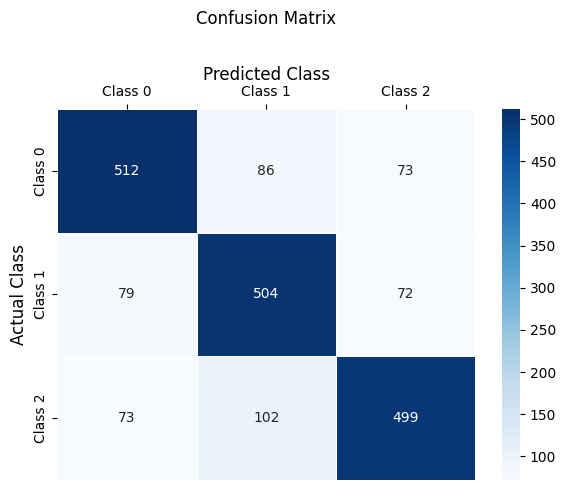

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_confusion_matrix(cm_A)

# One-vs-Rest Decomposition

In multiclass classification we can evaluate each class as if it were a binary problem:
- "positive" = this class $k$
- "negative" = all other classes $\neq k$

This is called one-vs-rest.

For a confusion matrix $CM \in \mathbb{R}^{K\times K}$ (rows=actual, columns = predicted), define for each class $k$:
- $TP_k = CM_{k,k}$ (True Positives)
- $FN_k = \sum_{j \neq k} CM_{k,j}$ (missed class $k$: actual $k$ predicted as not-$k$; False Negative)
- $FP_k = \sum_{i \neq k} CM_{i, k}$ (false alarms: predicted $k$ but actual not-$k$; False Positive)
- $TN_k = N - (TP_k + FP_k + FN_K)$ (True Negatives), $N=\sum_{i,j} CM_{i,j}$ is the total number of samples.



In [33]:
ovr_df = get_TP_FP_FN_TN(cm_A)
ovr_df

,class,TP,FP,FN,TN,support (actual count)
0,0,512,152,159,1177,671
1,1,504,188,151,1157,655
2,2,499,145,175,1181,674


# Precision

in progress

# Recall

# Precision-Recal Tradeoff

# F1 Score

# Accuracy

# Macro vs Micro vs Weighted

# Probabilistic Interpretation

# Cost-Sensitive Perspective

# Modern Extensions

# Ready-to-Use Libraries

# Summary

How to build the confusion matrix?

We want to classify cat vs dog, for cat class:

- True positive (TP): it is the total counts having both predicted and actual values are cat
- True negative (TN): it is the total counts having both predicted and actual values are dog (not cat)
- False positive (FP): it is the total counts having predicted cat and actual values are dog (not cat)
- False negative (FN): it is the total counts having predicted dog and actual values are cat

The confusion matrix is 2x2:
```
TP | FN 
-------
FP | TN
```
(columns = preds, rows = actual)

Actual (first 30):
[1 0 0 0 2 2 1 1 1 2 2 0 2 0 1 0 2 1 0 0 0 0 1 1 1 0 2 2 1 1]

Predictions (first 30):
[1 0 0 0 2 2 0 1 1 2 2 0 2 0 1 1 2 0 2 0 0 0 2 1 1 0 2 2 1 1]


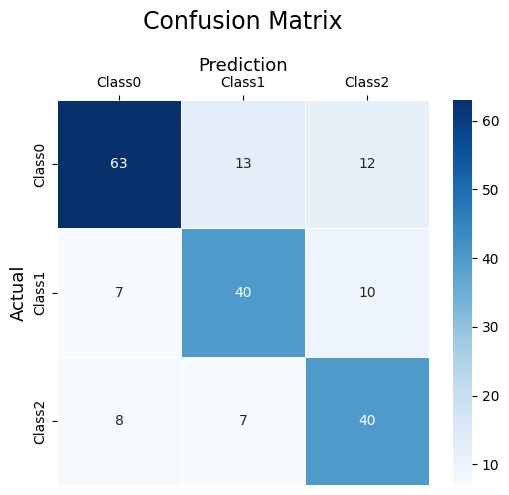

              precision    recall  f1-score   support

      Class0       0.81      0.72      0.76        88
      Class1       0.67      0.70      0.68        57
      Class2       0.65      0.73      0.68        55

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.72      0.71      0.72       200



In [20]:
### Generate data: actuals and predictions labels from experiment
rng = np.random.default_rng(0)

num_class = 3
num_samples = 200

# class distribution for y_true (must sum to 1, length = num_class)
probs_true = np.array([0.5, 0.3, 0.2])
y_true = rng.choice(num_class, size=num_samples, p=probs_true)
# print(f"Actual: \n{y_true}")

# "skill": probability of predicting correctly
p_correct = 0.75
y_pred = np.empty(num_samples, dtype=int)

for i, t in enumerate(y_true):
    if rng.random() < p_correct:
        y_pred[i] = t                          # correct => predict the true class
    else:
        # wrong => choose one of the other classes (uniformly)
        wrong_classes = [c for c in range(num_class) if c != t]
        y_pred[i] = rng.choice(wrong_classes)

print(f"Actual (first 30):\n{y_true[:30]}")
print(f"\nPredictions (first 30):\n{y_pred[:30]}")

### --- confusion matrix ---
labels = list(range(num_class))
cm = confusion_matrix(y_true, y_pred, labels=labels)
# print(cm)

# --- Plot ---
class_names = ["Class0", "Class1", "Class2"]  # rename e.g. ["Dog","Cat","Rabbit"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="Blues",              # <- blue palette
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white"
)
plt.ylabel("Actual", fontsize=13)
plt.title("Confusion Matrix", fontsize=17, pad=20)
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()
plt.show()

# --- Report ---
print(classification_report(y_true, y_pred, target_names=class_names))

# Metrics understanding

## Example: confusion matrix 3x3

In [22]:
# --- define 3x3 confusion matrix ---

cm = np.array([
    [40,  2,  3],
    [ 4, 30,  6],
    [ 1,  5, 35]
])

num_class = cm.shape[0]
num_samples = cm.sum()

print("Confusion matrix:\n", cm)
print("\nTotal samples:", num_samples)

Confusion matrix:
 [[40  2  3]
 [ 4 30  6]
 [ 1  5 35]]

Total samples: 126


The structure: for class $k$, we treat as one-vs-rest

- `TP_k = cm[k,k]`
- `FN_k = sum(row k) - TP_k`
- `FP_k = sum(col k) - TP_k`
- `TN_k = everything else`

In [ ]:
# --- compute TP, FP, FN, TN for each class
metrics = {}

for k in range(num_class):
    TP = cm[k,k]                # correctly predicted
    FN = cm[k,:].sum() - TP     # actual class predicted as something else
    FP = cm[:,k].sum() - TP     # predicted class but actually not class
    TN = num_samples - (TP+FN+FP) # everything else

    metrics[k] = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }

print(metrics)

{0: {'TP': np.int64(40), 'FP': np.int64(5), 'FN': np.int64(5), 'TN': np.int64(76)}, 1: {'TP': np.int64(30), 'FP': np.int64(7), 'FN': np.int64(10), 'TN': np.int64(79)}, 2: {'TP': np.int64(35), 'FP': np.int64(9), 'FN': np.int64(6), 'TN': np.int64(76)}}


1. Precision (for class k): $\frac{TP}{TP+FP}$; of all points predicted as class k, how many were correct?
2. Recall (for class k): $\frac{TP}{TP+FN}$; of all true class k points, how many did we capture?
3. F1 score: harmonic mean $2\frac{PR}{P+R}$; penalizes imbalance between precision (P) and recall (R)
4. Oveall accuracy: sum of diagonal / total

In [26]:
# --- compute precision, recall, F1 ---
for k in range(num_class):
    TP = metrics[k]["TP"]
    FP = metrics[k]["FP"]
    FN = metrics[k]["FN"]

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)

    metrics[k]["precision"] = precision
    metrics[k]["recall"] = recall
    metrics[k]["f1"] = f1

for k in range(num_class):
    print(f"\nClass {k}")
    for key, value in metrics[k].items():
        print(f"{key}: {value}")

accuracy = np.trace(cm) / num_samples
print("\nAccuracy:", accuracy)


Class 0
TP: 40
FP: 5
FN: 5
TN: 76
precision: 0.8888888888888888
recall: 0.8888888888888888
f1: 0.8888888888888888

Class 1
TP: 30
FP: 7
FN: 10
TN: 79
precision: 0.8108108108108109
recall: 0.75
f1: 0.7792207792207791

Class 2
TP: 35
FP: 9
FN: 6
TN: 76
precision: 0.7954545454545454
recall: 0.8536585365853658
f1: 0.8235294117647058

Accuracy: 0.8333333333333334


Intuition:

1. High precision for spam filter: emails flagged as spam are almost always spam
2. Low precision for spam filter: you lose important emails
3. High recall for cancer detection: you catch most sick patients
4. Low recall for cancer detection: many sick patients go undetected